# BIL 476 — Data Mining Project
## Market Basket Analysis: UCI Online Retail Dataset
**Student:** Erdem Baran  
**Student ID:** 211101034  
**Topic:** Market Basket Analysis (Topic 1)  
**Dataset:** UCI Online Retail — https://archive.ics.uci.edu/dataset/352/online+retail

---
## 0. Kütüphaneleri Yükle

In [4]:
# Gerekli kütüphaneleri yükle
!pip install mlxtend openpyxl seaborn matplotlib pandas numpy scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
import time

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Tüm kütüphaneler başarıyla yüklendi.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Tüm kütüphaneler başarıyla yüklendi.


---
## 1. Dataset Yükleme

UCI Online Retail dataset'ini Kaggle veya UCI'dan indirip aşağıdaki path'e koy:
- Dosya adı: `Online Retail.xlsx`
- Kaynak: https://archive.ics.uci.edu/dataset/352/online+retail
- Kaggle alternatif: https://www.kaggle.com/datasets/jihyeseo/online-retail-data-set-from-uci-ml-repo

In [5]:
# ---- Dataset yolu ----
DATA_PATH = 'Online Retail.xlsx'   # Aynı klasörde olmalı

print('Dataset yükleniyor... (xlsx için 30-60 sn sürebilir)')
df_raw = pd.read_excel(DATA_PATH, dtype={'CustomerID': str})
print(f'Ham dataset boyutu: {df_raw.shape[0]:,} satır x {df_raw.shape[1]} sütun')
df_raw.head()

Dataset yükleniyor... (xlsx için 30-60 sn sürebilir)
Ham dataset boyutu: 541,909 satır x 8 sütun


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


---
## 2. Temel Dataset Özellikleri (Section IV için)

In [8]:
print('=== TEMEL BİLGİLER ===')
print(f'Toplam satır: {len(df_raw):,}')
print(f'Toplam sütun: {df_raw.shape[1]}')
print(f'Sütunlar: {list(df_raw.columns)}')
print()
print('=== VERİ TİPLERİ ===')
print(df_raw.dtypes)
print()
print('=== EKSİK DEĞERLER ===')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Eksik %': missing_pct})
print(missing_df[missing_df['Eksik Sayı'] > 0])

=== TEMEL BİLGİLER ===
Toplam satır: 541,909
Toplam sütun: 8
Sütunlar: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

=== VERİ TİPLERİ ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

=== EKSİK DEĞERLER ===
             Eksik Sayı  Eksik %
Description        1454     0.27
CustomerID       135080    24.93


In [9]:
print('=== TANIMLAYICI İSTATİSTİKLER ===')
df_raw.describe(include='all').T

=== TANIMLAYICI İSTATİSTİKLER ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829,4372,17841,7983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Tarih aralığı ve ülke dağılımı
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
print(f'Tarih aralığı: {df_raw["InvoiceDate"].min().date()} → {df_raw["InvoiceDate"].max().date()}')
print(f'Benzersiz ülke sayısı: {df_raw["Country"].nunique()}')
print(f'Benzersiz müşteri sayısı: {df_raw["CustomerID"].nunique():,}')
print(f'Benzersiz ürün (StockCode) sayısı: {df_raw["StockCode"].nunique():,}')
print(f'Benzersiz fatura sayısı: {df_raw["InvoiceNo"].nunique():,}')

Tarih aralığı: 2010-12-01 → 2011-12-09
Benzersiz ülke sayısı: 38
Benzersiz müşteri sayısı: 4,372
Benzersiz ürün (StockCode) sayısı: 4,070
Benzersiz fatura sayısı: 25,900


---
## 3. Exploratory Data Analysis (EDA)

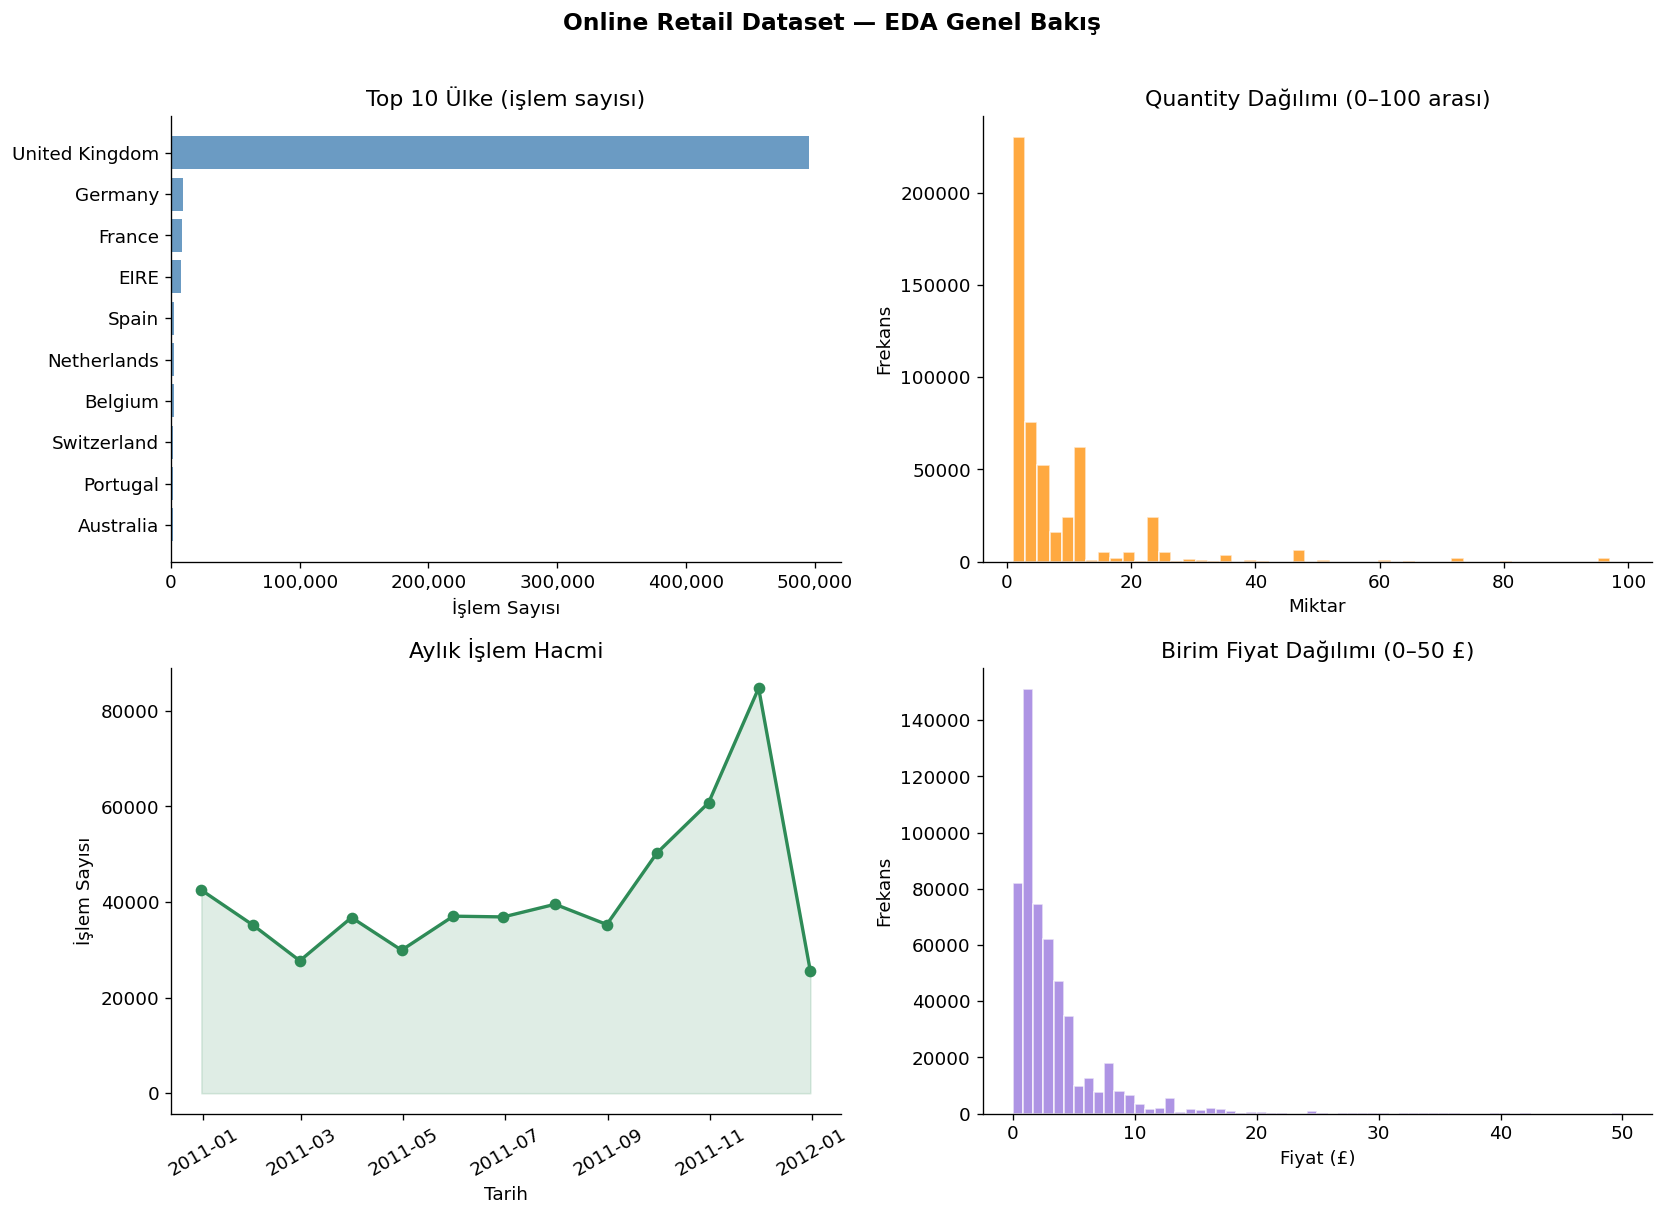

eda_overview.png kaydedildi.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Online Retail Dataset — EDA Genel Bakış', fontsize=14, fontweight='bold', y=1.01)

# 1. Ülke dağılımı (top 10)
top_countries = df_raw['Country'].value_counts().head(10)
axes[0,0].barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue', alpha=0.8)
axes[0,0].set_title('Top 10 Ülke (işlem sayısı)')
axes[0,0].set_xlabel('İşlem Sayısı')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2. Quantity dağılımı (pozitif değerler)
qty_pos = df_raw[df_raw['Quantity'] > 0]['Quantity']
axes[0,1].hist(qty_pos[qty_pos < 100], bins=50, color='darkorange', alpha=0.75, edgecolor='white')
axes[0,1].set_title('Quantity Dağılımı (0–100 arası)')
axes[0,1].set_xlabel('Miktar')
axes[0,1].set_ylabel('Frekans')

# 3. Aylık işlem sayısı
monthly = df_raw.set_index('InvoiceDate').resample('ME').size()
axes[1,0].plot(monthly.index, monthly.values, marker='o', color='seagreen', linewidth=2)
axes[1,0].fill_between(monthly.index, monthly.values, alpha=0.15, color='seagreen')
axes[1,0].set_title('Aylık İşlem Hacmi')
axes[1,0].set_xlabel('Tarih')
axes[1,0].set_ylabel('İşlem Sayısı')
axes[1,0].tick_params(axis='x', rotation=30)

# 4. UnitPrice dağılımı
price = df_raw[(df_raw['UnitPrice'] > 0) & (df_raw['UnitPrice'] < 50)]['UnitPrice']
axes[1,1].hist(price, bins=60, color='mediumpurple', alpha=0.75, edgecolor='white')
axes[1,1].set_title('Birim Fiyat Dağılımı (0–50 £)')
axes[1,1].set_xlabel('Fiyat (£)')
axes[1,1].set_ylabel('Frekans')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('eda_overview.png kaydedildi.')

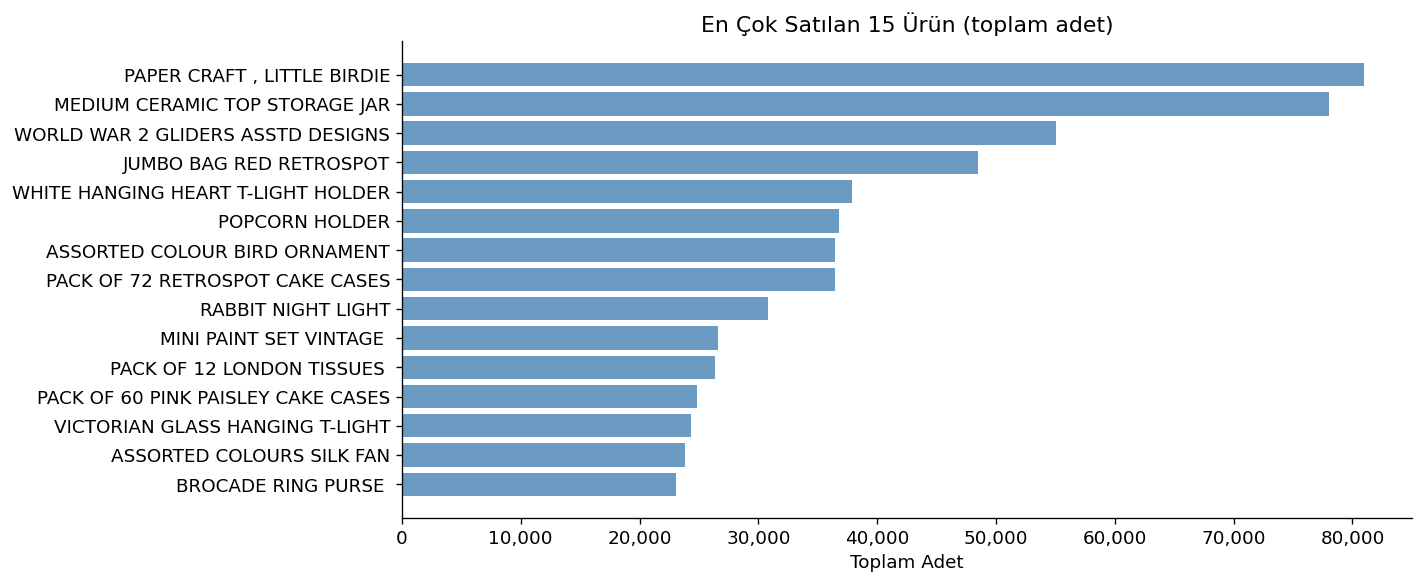

top_products.png kaydedildi.


In [12]:
# En çok satan ürünler
top_products = (df_raw[df_raw['Quantity'] > 0]
                .groupby('Description')['Quantity']
                .sum()
                .sort_values(ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_products.index[::-1], top_products.values[::-1], color='steelblue', alpha=0.8)
ax.set_title('En Çok Satılan 15 Ürün (toplam adet)')
ax.set_xlabel('Toplam Adet')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('top_products.png', bbox_inches='tight')
plt.show()
print('top_products.png kaydedildi.')

---
## 4. Preprocessing (Section V için)

**Adımlar ve gerekçeleri:**
1. İptal faturalar kaldırılır (C ile başlayanlar) — negatif işlemler modeli bozar
2. CustomerID eksik olan satırlar kaldırılır — anonim işlemler basket'e atanamaz
3. Negatif/sıfır Quantity kaldırılır — iade işlemleri
4. Sıfır/negatif UnitPrice kaldırılır — hatalı veri
5. Test ürünleri (M, D StockCode) kaldırılır
6. Odak: UK işlemleri (veri yoğunluğu için)

In [13]:
df = df_raw.copy()

n_before = len(df)
print(f'Ham veri: {n_before:,} satır')

# 1. İptal faturaları kaldır
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'İptal faturalar kaldırıldı: -{n_before - len(df):,} satır → {len(df):,} kaldı')

# 2. Eksik CustomerID kaldır
n = len(df)
df = df.dropna(subset=['CustomerID'])
print(f'Eksik CustomerID kaldırıldı: -{n - len(df):,} satır → {len(df):,} kaldı')

# 3. Negatif/sıfır Quantity kaldır
n = len(df)
df = df[df['Quantity'] > 0]
print(f'Geçersiz Quantity kaldırıldı: -{n - len(df):,} satır → {len(df):,} kaldı')

# 4. Geçersiz UnitPrice kaldır
n = len(df)
df = df[df['UnitPrice'] > 0]
print(f'Geçersiz UnitPrice kaldırıldı: -{n - len(df):,} satır → {len(df):,} kaldı')

# 5. Test ürünleri kaldır
n = len(df)
df = df[~df['StockCode'].astype(str).str.upper().isin(['M', 'D', 'DOT', 'PADS', 'POST', 'BANK CHARGES'])]
print(f'Test/servis ürünler kaldırıldı: -{n - len(df):,} satır → {len(df):,} kaldı')

# 6. Description temizle
df['Description'] = df['Description'].str.strip().str.upper()

print(f'\nTemizlenmiş veri: {len(df):,} satır ({len(df)/n_before*100:.1f}% kaldı)')

# Preprocessing özet tablosu (rapor için)
summary = pd.DataFrame({
    'Adım': ['Ham veri', 'İptal faturaları kaldır', 'Eksik CustomerID kaldır', 
             'Geçersiz Quantity kaldır', 'Geçersiz UnitPrice kaldır', 'Test ürünler kaldır'],
    'Kalan Satır': [n_before, 
                    n_before - df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')].shape[0],
                    None, None, None, len(df)]
})
print('\nPreprocessing özeti rapor için kaydedildi.')

Ham veri: 541,909 satır
İptal faturalar kaldırıldı: -9,288 satır → 532,621 kaldı
Eksik CustomerID kaldırıldı: -134,697 satır → 397,924 kaldı
Geçersiz Quantity kaldırıldı: -0 satır → 397,924 kaldı
Geçersiz UnitPrice kaldırıldı: -40 satır → 397,884 kaldı
Test/servis ürünler kaldırıldı: -1,414 satır → 396,470 kaldı

Temizlenmiş veri: 396,470 satır (73.2% kaldı)

Preprocessing özeti rapor için kaydedildi.


In [14]:
# UK odaklı analiz — en büyük pazar dilimi
df_uk = df[df['Country'] == 'United Kingdom'].copy()
print(f'UK verisi: {len(df_uk):,} satır')
print(f'UK benzersiz fatura: {df_uk["InvoiceNo"].nunique():,}')
print(f'UK benzersiz ürün: {df_uk["Description"].nunique():,}')

UK verisi: 354,015 satır
UK benzersiz fatura: 16,579
UK benzersiz ürün: 3,828


---
## 5. Transaction Matrisi Oluşturma

Her fatura = bir transaction. Ürün var mı/yok mu → binary matrix.

In [15]:
# Basket (transaction) matrisi: InvoiceNo × Description
print('Transaction matrisi oluşturuluyor...')
basket = (df_uk.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          .unstack(fill_value=0))

# Binary encode
basket_binary = basket.map(lambda x: 1 if x > 0 else 0)

print(f'Transaction matrisi boyutu: {basket_binary.shape[0]:,} fatura × {basket_binary.shape[1]:,} ürün')
print(f'Seyreklik (sparsity): {(basket_binary == 0).sum().sum() / basket_binary.size * 100:.1f}%')

# Ortalama sepet büyüklüğü
basket_sizes = basket_binary.sum(axis=1)
print(f'\nOrtalama sepet büyüklüğü: {basket_sizes.mean():.2f} ürün/fatura')
print(f'Medyan sepet büyüklüğü: {basket_sizes.median():.0f} ürün/fatura')
print(f'Max sepet büyüklüğü: {basket_sizes.max()} ürün/fatura')

Transaction matrisi oluşturuluyor...
Transaction matrisi boyutu: 16,579 fatura × 3,828 ürün
Seyreklik (sparsity): 99.5%

Ortalama sepet büyüklüğü: 20.75 ürün/fatura
Medyan sepet büyüklüğü: 15 ürün/fatura
Max sepet büyüklüğü: 540 ürün/fatura


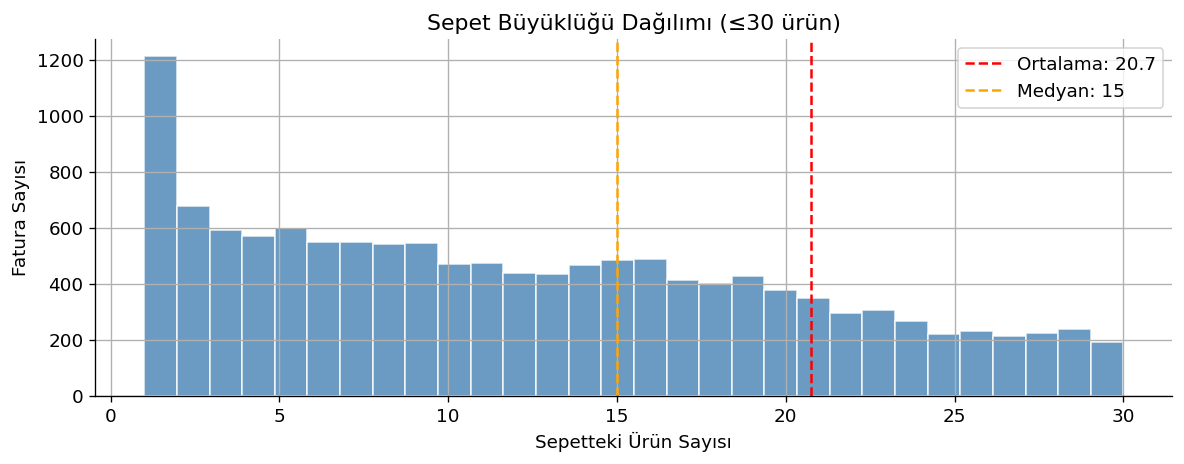

In [16]:
# Sepet büyüklüğü dağılımı
fig, ax = plt.subplots(figsize=(10, 4))
basket_sizes[basket_sizes <= 30].hist(bins=30, ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(basket_sizes.mean(), color='red', linestyle='--', label=f'Ortalama: {basket_sizes.mean():.1f}')
ax.axvline(basket_sizes.median(), color='orange', linestyle='--', label=f'Medyan: {basket_sizes.median():.0f}')
ax.set_title('Sepet Büyüklüğü Dağılımı (≤30 ürün)')
ax.set_xlabel('Sepetteki Ürün Sayısı')
ax.set_ylabel('Fatura Sayısı')
ax.legend()
plt.tight_layout()
plt.savefig('basket_size_dist.png', bbox_inches='tight')
plt.show()

---
## 6. Apriori vs FP-Growth Karşılaştırması

**Rubric gereksinimi:** Her iki algoritmayı efficiency ve scalability açısından karşılaştır.

In [17]:
MIN_SUPPORT = 0.02   # %2 minimum support — ayarlayabilirsin

print(f'=== APRIORI (min_support={MIN_SUPPORT}) ===')
t0 = time.time()
frequent_apriori = apriori(basket_binary, min_support=MIN_SUPPORT, use_colnames=True)
t_apriori = time.time() - t0
print(f'Süre: {t_apriori:.3f}s')
print(f'Bulunan frequent itemset sayısı: {len(frequent_apriori):,}')
print(f'Itemset boyut dağılımı:')
frequent_apriori['length'] = frequent_apriori['itemsets'].map(len)
print(frequent_apriori['length'].value_counts().sort_index())

print()
print(f'=== FP-GROWTH (min_support={MIN_SUPPORT}) ===')
t0 = time.time()
frequent_fp = fpgrowth(basket_binary, min_support=MIN_SUPPORT, use_colnames=True)
t_fpgrowth = time.time() - t0
print(f'Süre: {t_fpgrowth:.3f}s')
print(f'Bulunan frequent itemset sayısı: {len(frequent_fp):,}')

print()
print(f'=== KARŞILAŞTIRMA ===')
print(f'Apriori süresi:   {t_apriori:.3f}s')
print(f'FP-Growth süresi: {t_fpgrowth:.3f}s')
print(f'FP-Growth hız kazanımı: {t_apriori/t_fpgrowth:.1f}x daha hızlı')

=== APRIORI (min_support=0.02) ===
Süre: 3.266s
Bulunan frequent itemset sayısı: 239
Itemset boyut dağılımı:
length
1    203
2     35
3      1
Name: count, dtype: int64

=== FP-GROWTH (min_support=0.02) ===
Süre: 1.825s
Bulunan frequent itemset sayısı: 239

=== KARŞILAŞTIRMA ===
Apriori süresi:   3.266s
FP-Growth süresi: 1.825s
FP-Growth hız kazanımı: 1.8x daha hızlı


support=0.050: Apriori=0.529s, FP=1.467s, itemsets=19
support=0.040: Apriori=0.593s, FP=1.498s, itemsets=44
support=0.030: Apriori=0.818s, FP=1.743s, itemsets=90
support=0.020: Apriori=3.165s, FP=1.938s, itemsets=239
support=0.015: Apriori=8.007s, FP=2.161s, itemsets=446
support=0.010: Apriori=140.968s, FP=4.699s, itemsets=983


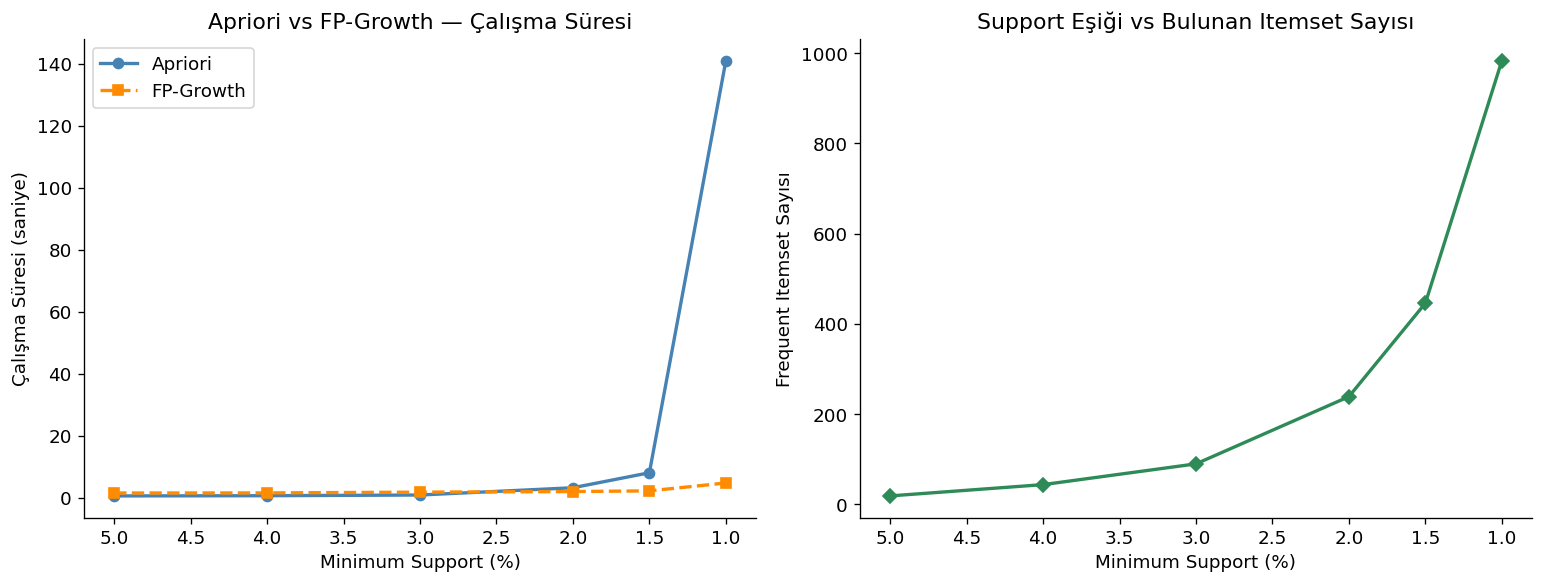

apriori_vs_fpgrowth.png kaydedildi.


In [18]:
# Farklı support değerlerinde süre karşılaştırması (scalability)
support_values = [0.05, 0.04, 0.03, 0.02, 0.015, 0.01]
times_apriori, times_fp, itemset_counts = [], [], []

for sup in support_values:
    t0 = time.time()
    fi = apriori(basket_binary, min_support=sup, use_colnames=True)
    times_apriori.append(time.time() - t0)
    
    t0 = time.time()
    fi2 = fpgrowth(basket_binary, min_support=sup, use_colnames=True)
    times_fp.append(time.time() - t0)
    
    itemset_counts.append(len(fi))
    print(f'support={sup:.3f}: Apriori={times_apriori[-1]:.3f}s, FP={times_fp[-1]:.3f}s, itemsets={len(fi)}')

# Grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot([s*100 for s in support_values], times_apriori, 'o-', label='Apriori', color='steelblue', linewidth=2)
ax1.plot([s*100 for s in support_values], times_fp, 's--', label='FP-Growth', color='darkorange', linewidth=2)
ax1.set_xlabel('Minimum Support (%)')
ax1.set_ylabel('Çalışma Süresi (saniye)')
ax1.set_title('Apriori vs FP-Growth — Çalışma Süresi')
ax1.legend()
ax1.invert_xaxis()

ax2.plot([s*100 for s in support_values], itemset_counts, 'D-', color='seagreen', linewidth=2)
ax2.set_xlabel('Minimum Support (%)')
ax2.set_ylabel('Frequent Itemset Sayısı')
ax2.set_title('Support Eşiği vs Bulunan Itemset Sayısı')
ax2.invert_xaxis()

plt.tight_layout()
plt.savefig('apriori_vs_fpgrowth.png', bbox_inches='tight')
plt.show()
print('apriori_vs_fpgrowth.png kaydedildi.')

---
## 7. Association Rule Mining & Interestingness Measures

**Rubric gereksinimi:** Support, Confidence, Lift + en az 1 null-invariant ölçüt (Kulczynski, Cosine)

In [19]:
# FP-Growth ile frequent itemsets (daha hızlı)
frequent_items = fpgrowth(basket_binary, min_support=0.02, use_colnames=True)

# Association rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1.0)
print(f'Toplam kural sayısı (lift ≥ 1): {len(rules):,}')
print()

# Null-invariant ölçütler ekle
def kulczynski(support_ab, support_a, support_b):
    """Kulczynski ölçütü: 0.5 * (P(A|B) + P(B|A))"""
    conf_ab = support_ab / support_a  # P(B|A)
    conf_ba = support_ab / support_b  # P(A|B)
    return 0.5 * (conf_ab + conf_ba)

def cosine_measure(support_ab, support_a, support_b):
    """Cosine (IS) ölçütü: P(A,B) / sqrt(P(A)*P(B))"""
    return support_ab / np.sqrt(support_a * support_b)

def all_confidence(support_ab, support_a, support_b):
    """All-confidence: support(A,B) / max(support(A), support(B))"""
    return support_ab / max(support_a, support_b)

rules['kulczynski'] = rules.apply(
    lambda r: kulczynski(r['support'], r['antecedent support'], r['consequent support']), axis=1)

rules['cosine'] = rules.apply(
    lambda r: cosine_measure(r['support'], r['antecedent support'], r['consequent support']), axis=1)

rules['all_confidence'] = rules.apply(
    lambda r: all_confidence(r['support'], r['antecedent support'], r['consequent support']), axis=1)

# Kuralları düzenle
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print('Ölçütler eklendi: kulczynski, cosine, all_confidence')
rules[['antecedents_str','consequents_str','support','confidence','lift',
       'kulczynski','cosine','all_confidence']].head(10)

Toplam kural sayısı (lift ≥ 1): 76

Ölçütler eklendi: kulczynski, cosine, all_confidence


,antecedents_str,consequents_str,support,confidence,lift,kulczynski,cosine,all_confidence
0,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.027625,0.536300,11.340962,0.560242,0.559730,0.536300
1,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.027625,0.584184,11.340962,0.560242,0.559730,0.536300
2,WHITE HANGING HEART T-LIGHT HOLDER,RED HANGING HEART T-LIGHT HOLDER,0.025816,0.227176,5.866596,0.446921,0.389167,0.227176
3,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.025816,0.666667,5.866596,0.446921,0.389167,0.227176
4,LUNCH BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT,0.022740,0.336607,3.856676,0.298573,0.296141,0.260539
5,JUMBO BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT,0.022740,0.260539,3.856676,0.298573,0.296141,0.260539
6,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.030521,0.623153,7.139771,0.486421,0.466808,0.349689
7,JUMBO BAG RED RETROSPOT,JUMBO BAG PINK POLKADOT,0.030521,0.349689,7.139771,0.486421,0.466808,0.349689
8,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.024609,0.566667,6.492582,0.424315,0.399723,0.281963
9,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,0.024609,0.281963,6.492582,0.424315,0.399723,0.281963


In [20]:
# Top 20 kural — lift'e göre sıralı
top_rules = rules.sort_values('lift', ascending=False).head(20)
display_cols = ['antecedents_str','consequents_str','support','confidence','lift','kulczynski','cosine']
top_rules[display_cols].round(4)

,antecedents_str,consequents_str,support,confidence,lift,kulczynski,cosine
59,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.0206,0.5572,24.1192,0.7238,0.7043
54,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.0206,0.8903,24.1192,0.7238,0.7043
57,PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.0206,0.6917,24.0912,0.7040,0.7039
56,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.0206,0.7164,24.0912,0.7040,0.7039
51,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0244,0.6601,22.1994,0.7398,0.7355
50,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0244,0.8195,22.1994,0.7398,0.7355
58,ROSES REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",0.0206,0.5029,20.6396,0.6735,0.6516
55,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.0206,0.8441,20.6396,0.6735,0.6516
49,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.0287,0.7778,19.0188,0.7399,0.7390
48,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0287,0.7021,19.0188,0.7399,0.7390


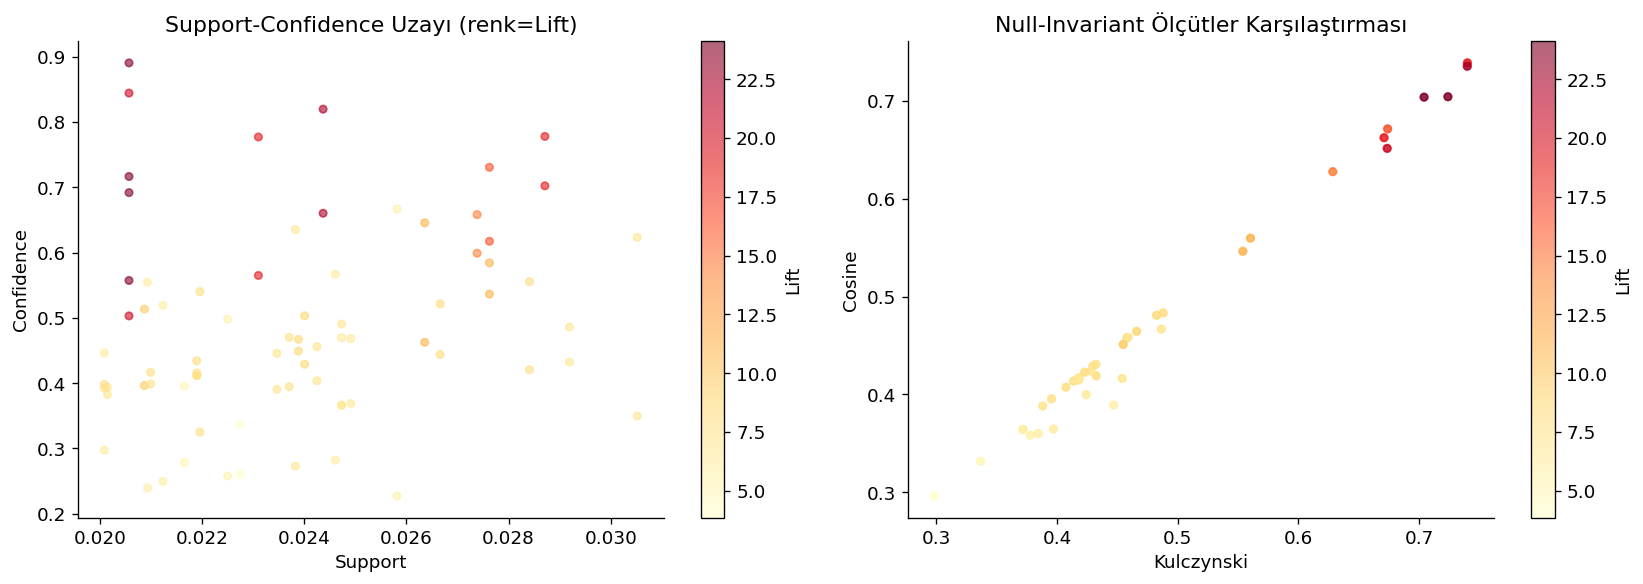

In [21]:
# Support-Confidence scatter plot (klasik görselleştirme)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support-Confidence Uzayı (renk=Lift)')

# Kulczynski vs Cosine
sc2 = axes[1].scatter(rules['kulczynski'], rules['cosine'],
                      c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=20)
plt.colorbar(sc2, ax=axes[1], label='Lift')
axes[1].set_xlabel('Kulczynski')
axes[1].set_ylabel('Cosine')
axes[1].set_title('Null-Invariant Ölçütler Karşılaştırması')

plt.tight_layout()
plt.savefig('rule_measures.png', bbox_inches='tight')
plt.show()

---
## 8. Misleading Rules Analizi (Discussion için)

**Rubric gereksinimi:** Yüksek confidence'a sahip ama aslında ilgisiz olan kuralları bul.

In [26]:
# Misleading rules analizi — gevşetilmiş eşikler
misleading = rules[(rules['confidence'] >= 0.3) & (rules['lift'] < 3.0)].sort_values('confidence', ascending=False)
print(f'Yüksek confidence (≥0.3) ama düşük lift (<3.0) kural sayısı: {len(misleading)}')
print('Bu kurallar support-confidence çerçevesinin yanıltıcılığını gösterir:')
misleading[['antecedents_str','consequents_str','support','confidence','lift','kulczynski']].head(10)

Yüksek confidence (≥0.3) ama düşük lift (<3.0) kural sayısı: 0
Bu kurallar support-confidence çerçevesinin yanıltıcılığını gösterir:


,antecedents_str,consequents_str,support,confidence,lift,kulczynski


=== ÖLÇÜT UYUŞMAZLIĞI ANALİZİ ===
Yüksek lift ama düşük Kulczynski:
  2 kural bulundu

Lift ve Kulczynski korelasyonu:
             lift  kulczynski  cosine  confidence  support
lift        1.000       0.953   0.954       0.758   -0.014
kulczynski  0.953       1.000   0.994       0.795    0.262
cosine      0.954       0.994   1.000       0.791    0.264
confidence  0.758       0.795   0.791       1.000    0.208
support    -0.014       0.262   0.264       0.208    1.000


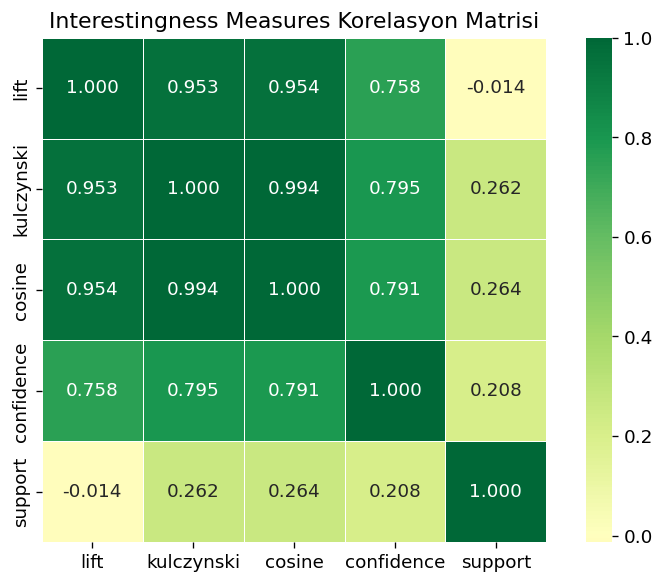

In [27]:
# Ölçüt uyuşmazlığı analizi — Discussion için kritik
print('=== ÖLÇÜT UYUŞMAZLIĞI ANALİZİ ===')
print('Yüksek lift ama düşük Kulczynski:')
disagreement = rules[(rules['lift'] > 3) & (rules['kulczynski'] < 0.3)]
print(f'  {len(disagreement)} kural bulundu')

print()
print('Lift ve Kulczynski korelasyonu:')
corr = rules[['lift', 'kulczynski', 'cosine', 'confidence', 'support']].corr()
print(corr.round(3))

# Korelasyon heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Interestingness Measures Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('measures_correlation.png', bbox_inches='tight')
plt.show()

---
## 9. Özet Raporu

IEEE raporunun Results bölümü için tüm temel değerler.

In [28]:
print('='*60)
print('PROJE ÖZET İSTATİSTİKLERİ (IEEE Raporu için)')
print('='*60)
print(f'\n[Dataset]')
print(f'  Ham kayıt sayısı:           {len(df_raw):,}')
print(f'  Temizlenmiş kayıt sayısı:   {len(df):,}')
print(f'  UK transaction sayısı:      {df_uk["InvoiceNo"].nunique():,}')
print(f'  Benzersiz ürün sayısı:      {basket_binary.shape[1]:,}')
print(f'  Ortalama sepet büyüklüğü:   {basket_binary.sum(axis=1).mean():.2f}')

print(f'\n[Association Rule Mining (support=0.02)]')
print(f'  Frequent itemset (Apriori):  {len(frequent_apriori):,}')
print(f'  Frequent itemset (FP-Gr.):   {len(frequent_fp):,}')
print(f'  Apriori süresi:              {t_apriori:.3f}s')
print(f'  FP-Growth süresi:            {t_fpgrowth:.3f}s')
print(f'  Toplam kural sayısı:         {len(rules):,}')

print(f'\n[Top Kural (lift\'e göre)]')
best = rules.sort_values('lift', ascending=False).iloc[0]
print(f'  Antecedent:  {best["antecedents_str"]}')
print(f'  Consequent:  {best["consequents_str"]}')
print(f'  Support:     {best["support"]:.4f}')
print(f'  Confidence:  {best["confidence"]:.4f}')
print(f'  Lift:        {best["lift"]:.4f}')
print(f'  Kulczynski:  {best["kulczynski"]:.4f}')
print(f'  Cosine:      {best["cosine"]:.4f}')
print('='*60)

PROJE ÖZET İSTATİSTİKLERİ (IEEE Raporu için)

[Dataset]
  Ham kayıt sayısı:           541,909
  Temizlenmiş kayıt sayısı:   396,470
  UK transaction sayısı:      16,579
  Benzersiz ürün sayısı:      3,828
  Ortalama sepet büyüklüğü:   20.75

[Association Rule Mining (support=0.02)]
  Frequent itemset (Apriori):  239
  Frequent itemset (FP-Gr.):   239
  Apriori süresi:              3.266s
  FP-Growth süresi:            1.825s
  Toplam kural sayısı:         76

[Top Kural (lift'e göre)]
  Antecedent:  GREEN REGENCY TEACUP AND SAUCER
  Consequent:  PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER
  Support:     0.0206
  Confidence:  0.5572
  Lift:        24.1192
  Kulczynski:  0.7238
  Cosine:      0.7043


In [29]:
# Sonuçları CSV'ye kaydet (rapor için)
rules[['antecedents_str','consequents_str','support','confidence','lift',
       'kulczynski','cosine','all_confidence']].sort_values('lift', ascending=False).to_csv(
    'association_rules_results.csv', index=False)
print('association_rules_results.csv kaydedildi.')

print('\nOluşturulan dosyalar:')
print('  eda_overview.png')
print('  top_products.png')
print('  basket_size_dist.png')
print('  apriori_vs_fpgrowth.png')
print('  rule_measures.png')
print('  measures_correlation.png')
print('  association_rules_results.csv')

association_rules_results.csv kaydedildi.

Oluşturulan dosyalar:
  eda_overview.png
  top_products.png
  basket_size_dist.png
  apriori_vs_fpgrowth.png
  rule_measures.png
  measures_correlation.png
  association_rules_results.csv
